# 1 Nonlinear Oscillator Markovian Sine-Drive Example

This example runs a Markovian waveguide simulation for one nonlinear harmonic oscillator driven by a sinusoidal classical field.

In [10]:
from __future__ import annotations

from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import time as t

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Examples":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import wqedmps as qmps


def run_markovian_nho_sine_drive_example(
    d_sys: int = 6,
    U: float = 0,
    show: bool = True,
) -> tuple[qmps.InputParams, qmps.Bins, dict[str, np.ndarray | float]]:
    """Run a 1-NHO Markovian example with a sinusoidal drive."""
    params = qmps.InputParams(
        delta_t=0.05,
        tmax=10.0,
        d_sys_total=np.array([d_sys]),
        d_t_total=np.array([2, 2]),
        gamma_l=0.5,
        gamma_r=0.5,
        U=U,
        bond_max=24,
        atol=1e-12,
    )

    drive_times = np.arange(params.steps) * params.delta_t
    drive = 1.2 * np.sin(1.6 * drive_times)

    initial_system = qmps.wg_ground(params.d_sys)
    initial_field = qmps.vacuum(params.tmax, params)

    start_time = t.time()
    hamiltonian = qmps.hamiltonian_1nho(params, omega=drive, delta=0.0)
    bins = qmps.t_evol_mar_seemps(
        hamiltonian,
        initial_system,
        initial_field,
        params,
    )

    times = np.asarray(bins.times, dtype=float)
    nho_pop = np.asarray(
        qmps.single_time_expectation(bins.system_states, qmps.num_op(params.d_sys)),
        dtype=float,
    )
    output_bin_pop = np.asarray(
        qmps.single_time_expectation(
            bins.output_field_states,
            [qmps.num_op_l(params.d_t_total), qmps.num_op_r(params.d_t_total)],
        ),
        dtype=float,
    )
    photon_bins_l = output_bin_pop[0] / params.delta_t
    photon_bins_r = output_bin_pop[1] / params.delta_t
    emitted_l = np.concatenate([[0.0], np.cumsum(photon_bins_l[1:])]) * params.delta_t
    emitted_r = np.concatenate([[0.0], np.cumsum(photon_bins_r[1:])]) * params.delta_t
    total_quanta = nho_pop + emitted_l + emitted_r
    runtime = float(t.time() - start_time)
    print("--- %s seconds ---" % runtime)

    observables = {
        "times": times,
        "drive_times": drive_times,
        "drive": drive,
        "nho_pop": nho_pop,
        "photon_bins_l": photon_bins_l,
        "photon_bins_r": photon_bins_r,
        "emitted_l": emitted_l,
        "emitted_r": emitted_r,
        "total_quanta": total_quanta,
        "runtime": runtime,
    }

    if show:
        fig, axes = plt.subplots(3, 1, figsize=(8.0, 8.5), sharex=True)

        axes[0].plot(
            drive_times, drive, lw=2.5, label=r"$\Omega(t) = \Omega_0 \sin(\nu t)$"
        )
        axes[0].set_ylabel("Drive")
        axes[0].set_title("1 nonlinear oscillator in the Markovian waveguide")
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        axes[1].plot(times, nho_pop, lw=2.5, label="Oscillator occupation")
        axes[1].plot(times, photon_bins_l, lw=2.5, label="Left-bin expectation")
        axes[1].plot(times, photon_bins_r, lw=2.5, label="Right-bin expectation")
        axes[1].set_ylabel("Occupation")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        axes[2].plot(
            times, nho_pop, lw=2.5, label=r"$\langle n_\mathrm{sys}(t) \rangle$"
        )
        axes[2].plot(times, emitted_l, lw=2.5, label=r"$N_L(t)$")
        axes[2].plot(times, emitted_r, lw=2.5, label=r"$N_R(t)$")
        axes[2].plot(times, total_quanta, lw=2.5, label="System + emitted")
        axes[2].set_xlabel("Time")
        axes[2].set_ylabel("Integrated quanta")
        axes[2].legend()
        axes[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return params, bins, observables


# params, bins, observables = run_markovian_nho_sine_drive_example(U=0)


--- 0.10170483589172363 seconds ---
--- 0.11126255989074707 seconds ---


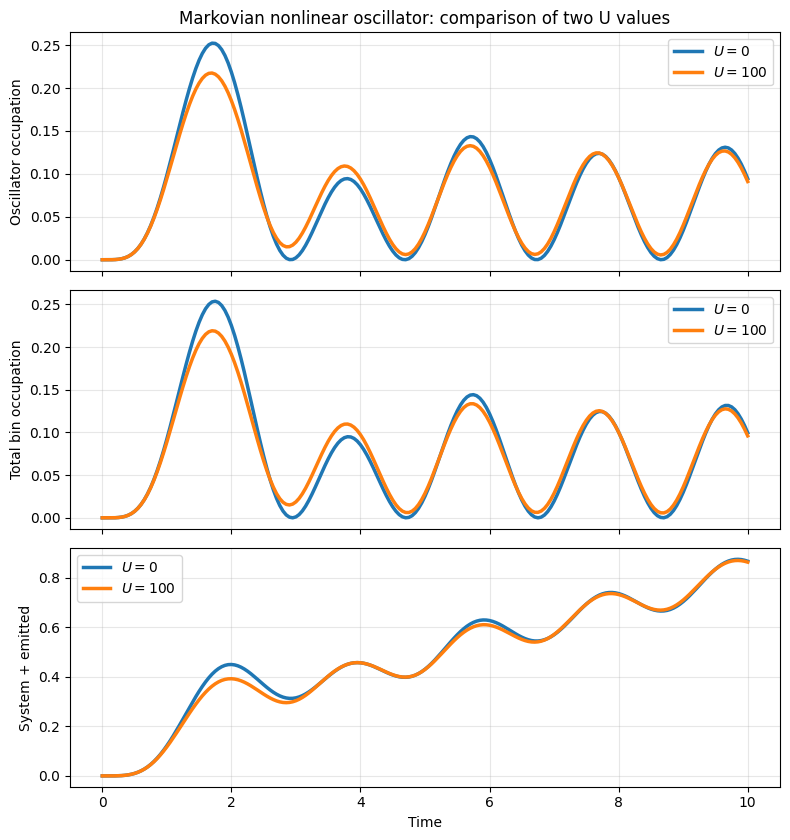

In [ ]:
compare_u_values = [0.0, 100]
compare_results = {}

for U_value in compare_u_values:
    _, _, compare_results[U_value] = run_markovian_nho_sine_drive_example(
        U=U_value, show=False, d_sys=10
    )

times = compare_results[compare_u_values[0]]["times"]

fig, axes = plt.subplots(3, 1, figsize=(8.0, 8.5), sharex=True)

for U_value in compare_u_values:
    result = compare_results[U_value]
    axes[0].plot(times, result["nho_pop"], lw=2.5, label=rf"$U={U_value:g}$")
axes[0].set_ylabel("Oscillator occupation")
axes[0].set_title("Markovian nonlinear oscillator: comparison of two U values")
axes[0].legend()
axes[0].grid(alpha=0.3)

for U_value in compare_u_values:
    result = compare_results[U_value]
    total_bin = result["photon_bins_l"] + result["photon_bins_r"]
    axes[1].plot(times, total_bin, lw=2.5, label=rf"$U={U_value:g}$")
axes[1].set_ylabel("Total bin occupation")
axes[1].legend()
axes[1].grid(alpha=0.3)

for U_value in compare_u_values:
    result = compare_results[U_value]
    axes[2].plot(times, result["total_quanta"], lw=2.5, label=rf"$U={U_value:g}$")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("System + emitted")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
